# Architecture Comparison: Does the Bottleneck Shape What Gets Learned?

This experiment trains four autoencoder architectures on identical data
and compares what each one learns. The question is whether architecture
matters — do different bottlenecks impose different inductive biases on
the learned feature geometry, even when the data, training budget,
and hyperparameters are held constant?

Architectures tested:
1. **TiedLinearRelu** — Linear encoder with tied decoder + ReLU. The standard baseline.
2. **TiedLinear** — Same as above but without ReLU on the decoder output.
3. **MLPEncoder** — Independent 2-layer MLP encoder and decoder. No weight tying.
4. **TiedMLPEncoder** — MLP encoder with tied (transposed) decoder weights.

Setup: 50 features compressed into 15 hidden dimensions (3.3x compression),
with 1% feature activation probability and exponentially decaying importances.

In [1]:
import plotly.io as pio

pio.renderers.default = "png"

import torch
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from occhio import ToyModel
from occhio.autoencoders import (
    TiedLinearRelu,
    TiedLinear,
    MLPEncoder,
    TiedMLPEncoder,
)
from occhio.distributions import SparseUniform

In [2]:
# -- Shared experiment parameters --

N_FEATURES = 50
N_HIDDEN = 15
N_EPOCHS = 25000
BATCH_SIZE = 1024
LR = 3e-4
P_ACTIVE = 0.01
SEED = 42
DEVICE = "cpu"

# Importance decay: feature 0 is most important, decaying by 0.9x per feature
importances = torch.tensor([0.9**i for i in range(N_FEATURES)])

print(f"Compression ratio: {N_FEATURES / N_HIDDEN:.1f}x")
print(f"Expected active features per sample: {N_FEATURES * P_ACTIVE:.1f}")
print(f"Importance range: {importances[0]:.3f} (f0) -> {importances[-1]:.6f} (f49)")

Compression ratio: 3.3x
Expected active features per sample: 0.5
Importance range: 1.000 (f0) -> 0.005726 (f49)


## Build and Train All Architectures

Each architecture sees exactly the same SparseUniform distribution.
We use a fresh random generator per architecture so weight initialization
differs but training data is sampled identically.

In [3]:
def make_generator():
    """Fresh generator with the same seed for fair comparison."""
    return torch.Generator(DEVICE).manual_seed(SEED)


# Shared distribution
dist = SparseUniform(N_FEATURES, p_active=P_ACTIVE, device=DEVICE)

# Build one ToyModel per architecture
models = {}

# 1. TiedLinearRelu — the standard baseline from Toy Models of Superposition
ae_relu = TiedLinearRelu(
    N_FEATURES, N_HIDDEN, device=DEVICE, generator=make_generator()
)
models["TiedLinearRelu"] = ToyModel(dist, ae_relu, importances=importances)

# 2. TiedLinear — no ReLU on decoder output. Tests whether the nonlinearity
#    is necessary or whether tied weights alone suffice.
ae_linear = TiedLinear(N_FEATURES, N_HIDDEN, device=DEVICE, generator=make_generator())
models["TiedLinear"] = ToyModel(dist, ae_linear, importances=importances)

# 3. MLPEncoder — 2-layer MLP with independent encoder/decoder.
#    More parameters, but no weight-sharing constraint.
ae_mlp = MLPEncoder(
    embedding=[N_FEATURES, 30, N_HIDDEN],
    unembedding=[N_HIDDEN, 30, N_FEATURES],
    device=DEVICE,
    generator=make_generator(),
)
models["MLPEncoder"] = ToyModel(dist, ae_mlp, importances=importances)

# 4. TiedMLPEncoder — MLP encoder with tied (transposed) decoder weights.
#    Combines MLP expressiveness with the regularization of weight tying.
ae_tied_mlp = TiedMLPEncoder(
    dims=[N_FEATURES, 30, N_HIDDEN],
    device=DEVICE,
    generator=make_generator(),
)
models["TiedMLPEncoder"] = ToyModel(dist, ae_tied_mlp, importances=importances)

print("Models built. Parameter counts:")
for name, tm in models.items():
    n_params = sum(p.numel() for p in tm.ae.parameters())
    print(f"  {name}: {n_params:,} parameters")

Models built. Parameter counts:
  TiedLinearRelu: 800 parameters
  TiedLinear: 800 parameters
  MLPEncoder: 4,025 parameters
  TiedMLPEncoder: 2,075 parameters


In [4]:
# -- Train all architectures --

all_losses = {}
for name, tm in models.items():
    print(f"Training {name}...")
    losses, _ = tm.fit(
        N_EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LR,
        verbose=False,
    )
    all_losses[name] = losses
    print(f"  Final loss: {losses[-1]:.6f}")

Training TiedLinearRelu...


  Final loss: 0.000677
Training TiedLinear...


  Final loss: 0.008370
Training MLPEncoder...


  Final loss: 0.013824
Training TiedMLPEncoder...


  Final loss: 0.000519


## Plot 1: Training Loss Curves

All four architectures on the same log-scale y-axis.
This reveals both convergence speed and final loss quality.

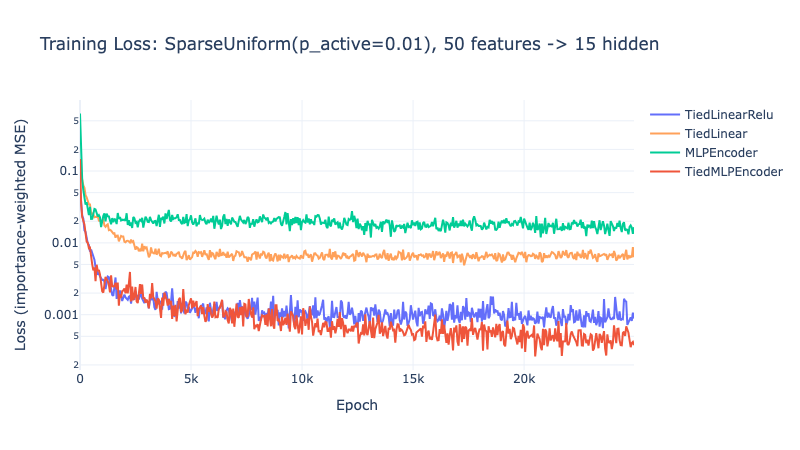

In [5]:
colors = {
    "TiedLinearRelu": "#636EFA",
    "TiedLinear": "#FFA15A",
    "MLPEncoder": "#00CC96",
    "TiedMLPEncoder": "#EF553B",
}

fig_loss = go.Figure()
for name, losses in all_losses.items():
    # Subsample to 500 points for readability
    step = max(1, len(losses) // 500)
    epochs = list(range(0, len(losses), step))
    sampled = [losses[i] for i in epochs]
    fig_loss.add_trace(
        go.Scatter(
            x=epochs,
            y=sampled,
            mode="lines",
            name=name,
            line=dict(color=colors[name], width=2),
        )
    )

fig_loss.update_layout(
    title="Training Loss: SparseUniform(p_active=0.01), 50 features -> 15 hidden",
    xaxis_title="Epoch",
    yaxis_title="Loss (importance-weighted MSE)",
    yaxis_type="log",
    template="plotly_white",
    height=450,
    width=800,
)
fig_loss.show()

## Plot 2: Superposition Metric

The superposition metric (rho_mm) measures mean max absolute cosine
similarity between feature embeddings. Values close to 0 mean features
are nearly orthogonal (no superposition); values close to 1 mean heavy
overlap. With 50 features in 15 dimensions, some superposition is
inevitable — the question is how much each architecture produces.

Architecture           Final Loss  Superposition
------------------------------------------------
TiedLinearRelu           0.000677         0.7222
TiedLinear               0.008370         0.6591
MLPEncoder               0.013824         0.9073
TiedMLPEncoder           0.000519         0.7856


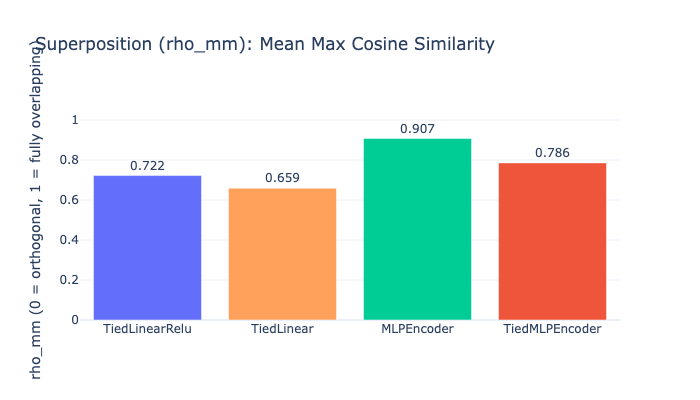

In [6]:
# Collect metrics
arch_names = list(models.keys())
superpositions = [models[n].superposition.item() for n in arch_names]
final_losses = [all_losses[n][-1] for n in arch_names]

# Print summary table
print(f"{'Architecture':<20} {'Final Loss':>12} {'Superposition':>14}")
print("-" * 48)
for name, loss, sup in zip(arch_names, final_losses, superpositions):
    print(f"{name:<20} {loss:>12.6f} {sup:>14.4f}")

# Bar chart
fig_sup = go.Figure()
fig_sup.add_trace(
    go.Bar(
        x=arch_names,
        y=superpositions,
        marker_color=[colors[n] for n in arch_names],
        text=[f"{s:.3f}" for s in superpositions],
        textposition="outside",
    )
)
fig_sup.update_layout(
    title="Superposition (rho_mm): Mean Max Cosine Similarity",
    yaxis_title="rho_mm (0 = orthogonal, 1 = fully overlapping)",
    yaxis_range=[0, 1.1],
    template="plotly_white",
    height=400,
    width=700,
    showlegend=False,
)
fig_sup.show()

## Plot 3: Feature Norms

Feature norms (||w_i||) show how much capacity the model allocates
to each feature. With exponentially decaying importances, we expect
higher-importance features (lower index) to receive larger norms.
The shape of this curve reveals the architecture's allocation strategy.

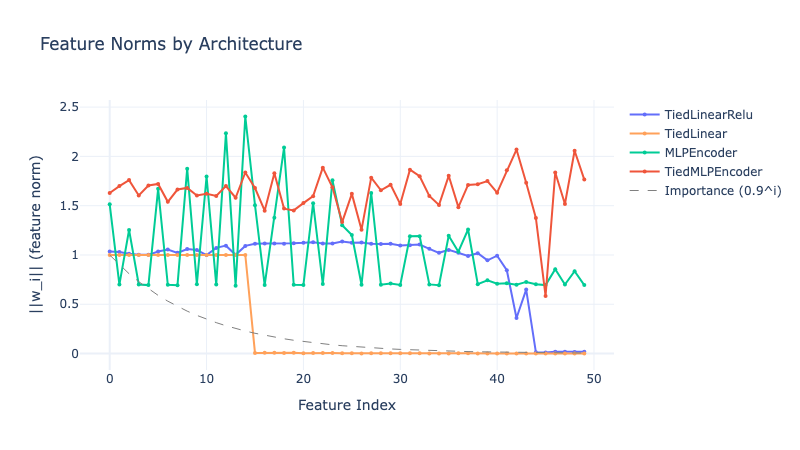

In [7]:
fig_norms = go.Figure()
for name, tm in models.items():
    norms = tm.feature_norms.cpu().numpy()
    fig_norms.add_trace(
        go.Scatter(
            x=list(range(N_FEATURES)),
            y=norms,
            mode="lines+markers",
            name=name,
            line=dict(color=colors[name], width=2),
            marker=dict(size=4),
        )
    )

# Overlay the importance curve for reference
fig_norms.add_trace(
    go.Scatter(
        x=list(range(N_FEATURES)),
        y=importances.numpy(),
        mode="lines",
        name="Importance (0.9^i)",
        line=dict(color="gray", width=1, dash="dash"),
    )
)

fig_norms.update_layout(
    title="Feature Norms by Architecture",
    xaxis_title="Feature Index",
    yaxis_title="||w_i|| (feature norm)",
    template="plotly_white",
    height=450,
    width=800,
)
fig_norms.show()

## Analysis

Detailed comparison across all four architectures, including
feature dimensionalities and interference structure.

In [8]:
# Detailed metrics table
print(
    f"{'Architecture':<20} {'Loss':>8} {'Superpos.':>10} "
    f"{'Mean Dim':>10} {'Mean Norm':>10} {'Params':>8}"
)
print("-" * 70)
for name, tm in models.items():
    loss = all_losses[name][-1]
    sup = tm.superposition.item()
    mean_dim = tm.feature_dimensionalities.cpu().numpy().mean()
    mean_norm = tm.feature_norms.cpu().numpy().mean()
    n_params = sum(p.numel() for p in tm.ae.parameters())
    print(
        f"{name:<20} {loss:>8.5f} {sup:>10.4f} "
        f"{mean_dim:>10.4f} {mean_norm:>10.4f} {n_params:>8,}"
    )

print("\n--- Key Observations ---")
print()

# Find best/worst
best_name = min(all_losses, key=lambda n: all_losses[n][-1])
worst_name = max(all_losses, key=lambda n: all_losses[n][-1])
best_loss = all_losses[best_name][-1]
worst_loss = all_losses[worst_name][-1]

print(f"Best final loss:  {best_name} ({best_loss:.6f})")
print(f"Worst final loss: {worst_name} ({worst_loss:.6f})")
print(f"Loss ratio (worst/best): {worst_loss / best_loss:.1f}x")
print()

lowest_sup_name = min(models, key=lambda n: models[n].superposition.item())
highest_sup_name = max(models, key=lambda n: models[n].superposition.item())
print(
    f"Lowest superposition:  {lowest_sup_name} "
    f"({models[lowest_sup_name].superposition.item():.4f})"
)
print(
    f"Highest superposition: {highest_sup_name} "
    f"({models[highest_sup_name].superposition.item():.4f})"
)

Architecture             Loss  Superpos.   Mean Dim  Mean Norm   Params
----------------------------------------------------------------------
TiedLinearRelu        0.00068     0.7222     0.2952     0.9144      800
TiedLinear            0.00837     0.6591     0.3000     0.3022      800
MLPEncoder            0.01382     0.9073     0.0404     1.0470    4,025
TiedMLPEncoder        0.00052     0.7856     0.0503     1.6412    2,075

--- Key Observations ---

Best final loss:  TiedMLPEncoder (0.000519)
Worst final loss: MLPEncoder (0.013824)
Loss ratio (worst/best): 26.7x

Lowest superposition:  TiedLinear (0.6591)
Highest superposition: MLPEncoder (0.9073)
